In [ ]:
!git clone https://github.com/UCT-Advanced-Image-Analysis/semester-project-2026.git

Cloning into 'semester-project-2026'...
remote: Enumerating objects: 846, done.
remote: Counting objects: 100% (390/390), done.
remote: Compressing objects: 100% (177/177), done.
remote: Total 846 (delta 295), reused 253 (delta 209), pack-reused 456 (from 1)
Receiving objects: 100% (846/846), 13.69 MiB | 10.26 MiB/s, done.
Resolving deltas: 100% (426/426), done.
Updating files: 100% (611/611), done.


In [ ]:
# The only extra install you might need
!pip install pingouin -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 2.7 MB/s eta 0:00:00


In [ ]:


import pandas as pd
import pingouin as pg
from sklearn.metrics import cohen_kappa_score

In [ ]:
import glob
import os

search_path = '/content/semester-project-2026/images'
pattern = os.path.join(search_path, '**', 'student_*.csv')

found_files = glob.glob(pattern, recursive=True)

if found_files:
    print("Found 'student_*.csv' files:")
    for file_path in found_files:
        print(file_path)
else:
    print("No 'student_*.csv' files found in the specified path.")

Found 'student_*.csv' files:
/content/semester-project-2026/images/student_02/student_02_counts.csv
/content/semester-project-2026/images/student_06/student_06_counts.csv
/content/semester-project-2026/images/student_07/student_07_counts.csv
/content/semester-project-2026/images/student_09/student_09_counts.csv
/content/semester-project-2026/images/student_03/student_03_counts.csv
/content/semester-project-2026/images/student_08/student_08_counts.csv
/content/semester-project-2026/images/student_05/student_05_counts.csv
/content/semester-project-2026/images/student_04/student_04_counts.csv


Load CSV

In [ ]:
import pandas as pd
import re
import os

data = []
for file_path in found_files:
    filename = os.path.basename(file_path)
    match = re.search(r'student_(\d+)_counts\.csv', filename)
    if match:
        student_number = match.group(1)
        data.append({'student_number': student_number, 'path': file_path})

student_df = pd.DataFrame(data)
display(student_df.head())

,student_number,path
0,02,/content/semester-project-2026/images/student_...
1,06,/content/semester-project-2026/images/student_...
2,07,/content/semester-project-2026/images/student_...
3,09,/content/semester-project-2026/images/student_...
4,03,/content/semester-project-2026/images/student_...


Load file mapping from blind file mixing

In [ ]:
url = 'https://github.com/UCT-Advanced-Image-Analysis/semester-project-2026-eval/raw/refs/heads/main/tables/image_mapping_v2.csv'
image_mapping_df = pd.read_csv(url)
display(image_mapping_df.head())

,original_path,student_folder,new_filename,image_type
0,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_5.tif,calibration
1,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_13.tif,calibration
2,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_14.tif,calibration
3,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_8.tif,calibration
4,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_11.tif,duplicate


In [ ]:
image_mapping_df['original_filename'] = image_mapping_df['original_path'].apply(lambda x: x.split('/')[-1].replace('.tif', ''))
display(image_mapping_df.head())

,original_path,student_folder,new_filename,image_type,original_filename
0,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_5.tif,calibration,9GRAY_015-cropped
1,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_13.tif,calibration,16GRAY_045-cropped
2,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_14.tif,calibration,4GRAY_000-cropped
3,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_8.tif,calibration,1GRAY_030-cropped
4,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_11.tif,duplicate,12GRAY_015-cropped


Load numbers from correct images

In [ ]:
student_dataframes = {}

for index, row in student_df.iterrows():
    student_number = row['student_number']
    file_path = row['path']

    # Load the CSV file, using ';' as a separator
    df_student = pd.read_csv(file_path, sep=';', header=0, index_col=None, encoding='utf-8')

    # Add the 'student_folder' column
    df_student['student_folder'] = 'student_' + student_number

    # Store the DataFrame in the dictionary
    student_dataframes[student_number] = df_student


print(f"Loaded data for {len(student_dataframes)} students.")

# Display the head of one of the student dataframes as an example
if student_dataframes:
    first_student_key = list(student_dataframes.keys())[0]
    print(f"\nDisplaying head for student {first_student_key}:")
    display(student_dataframes[first_student_key].head())

Loaded data for 8 students.

Displaying head for student 02:


,image_name,manual_count,script_own,script_simple,script_watershed,script_own_sparse,script_SarDist,YOLO_count,student_folder
0,img_01,81,60,48,73,58,71,NaN,student_02
1,img_02,83,78,60,83,76,81,NaN,student_02
2,img_03,88,56,46,83,57,82,NaN,student_02
3,img_04,75,58,46,68,59,64,NaN,student_02
4,img_05,56,45,36,53,45,53,NaN,student_02


In [ ]:
import re

for student_number, df_student in student_dataframes.items():
    # Standardize image_name to match the format in image_mapping_df (e.g., 'img_1.tif' instead of 'img_01.tif')
    # First, ensure it's a string and remove any existing '.tif' for consistent processing
    df_student['image_name'] = df_student['image_name'].astype(str).str.replace('\.tif$', '', regex=True)
    # Then, remove leading zeros from the numeric part of the image name
    df_student['image_name'] = df_student['image_name'].apply(lambda x: re.sub(r'img_0*(\d+)$', r'img_\1', x)) + '.tif'
    student_dataframes[student_number] = df_student

print("Standardized 'image_name' column formatting in all student dataframes.")

# Display the head of one of the updated student dataframes as an example
if student_dataframes:
    first_student_key = list(student_dataframes.keys())[0]
    print(f"\nDisplaying head for standardized student {first_student_key}:")
    display(student_dataframes[first_student_key].head())

Standardized 'image_name' column formatting in all student dataframes.

Displaying head for standardized student 02:


<>:6: SyntaxWarning: invalid escape sequence '\.'
<>:6: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_2859/2773219164.py:6: SyntaxWarning: invalid escape sequence '\.'
  df_student['image_name'] = df_student['image_name'].astype(str).str.replace('\.tif$', '', regex=True)


,image_name,manual_count,script_own,script_simple,script_watershed,script_own_sparse,script_SarDist,YOLO_count,student_folder
0,img_1.tif,81,60,48,73,58,71,NaN,student_02
1,img_2.tif,83,78,60,83,76,81,NaN,student_02
2,img_3.tif,88,56,46,83,57,82,NaN,student_02
3,img_4.tif,75,58,46,68,59,64,NaN,student_02
4,img_5.tif,56,45,36,53,45,53,NaN,student_02


In [ ]:
for student_number, df_student in student_dataframes.items():
    # Merge with image_mapping_df using 'student_folder' and 'image_name' (from df_student)
    # and 'new_filename' (from image_mapping_df)
    merged_df = pd.merge(
        df_student,
        image_mapping_df[['student_folder', 'new_filename', 'image_type', 'original_filename']],
        left_on=['student_folder', 'image_name'],
        right_on=['student_folder', 'new_filename'],
        how='left'
    )
    # Drop the redundant 'new_filename' column from the merge if it exists
    # Note: 'new_filename' is from image_mapping_df, which we don't want to keep in the final student_df
    merged_df = merged_df.drop(columns=['new_filename'])
    student_dataframes[student_number] = merged_df

print("Updated student_dataframes with image_type and original_filename.")

# Display the head of one of the updated student dataframes as an example
if student_dataframes:
    first_student_key = list(student_dataframes.keys())[0]
    print(f"\nDisplaying head for updated student {first_student_key}:")
    display(student_dataframes[first_student_key].head())

Updated student_dataframes with image_type and original_filename.

Displaying head for updated student 02:


,image_name,manual_count,script_own,script_simple,script_watershed,script_own_sparse,script_SarDist,YOLO_count,student_folder,image_type,original_filename
0,img_1.tif,81,60,48,73,58,71,NaN,student_02,calibration,9GRAY_015-cropped
1,img_2.tif,83,78,60,83,76,81,NaN,student_02,unique_random,17GRAY_000-cropped
2,img_3.tif,88,56,46,83,57,82,NaN,student_02,unique_random,5GRAY_045-cropped
3,img_4.tif,75,58,46,68,59,64,NaN,student_02,duplicate,12GRAY_015-cropped
4,img_5.tif,56,45,36,53,45,53,NaN,student_02,unique_random,19GRAY_030-cropped


In [ ]:
df_student = student_dataframes[first_student_key]
df_student[df_student['image_type']=='calibration']

,image_name,manual_count,script_own,script_simple,script_watershed,script_own_sparse,script_SarDist,YOLO_count,student_folder,image_type,original_filename
0,img_1.tif,81,60,48,73,58,71,NaN,student_02,calibration,9GRAY_015-cropped
7,img_8.tif,58,46,37,55,46,55,NaN,student_02,calibration,1GRAY_030-cropped
9,img_10.tif,77,73,60,77,73,75,NaN,student_02,calibration,4GRAY_000-cropped
14,img_15.tif,64,43,33,57,43,51,NaN,student_02,calibration,16GRAY_045-cropped


In [ ]:
import pandas as pd

# Concatenate all student dataframes into one big table
all_students_df = pd.concat(student_dataframes.values(), ignore_index=True)

# Add a new column 'student' as a duplicate of 'student_folder'
all_students_df['student'] = all_students_df['student_folder']

# Extract 'xx' from 'student_folder'
xx = all_students_df['student_folder'].str.extract(r'student_(\d+)').iloc[:, 0]

# Extract 'yy' from 'image_name' (assuming image_name always ends with .tif)
yy = all_students_df['image_name'].str.extract(r'img_(\d+)\.tif').iloc[:, 0]

# Create the new 'path' column
all_students_df['path'] = 'student_' + xx + '/img_' + yy + '.tiff'

# Display the head of the new big table
all_students_df.head()

,image_name,manual_count,script_own,script_simple,script_watershed,script_own_sparse,script_SarDist,YOLO_count,student_folder,image_type,original_filename,student,path
0,img_1.tif,81.0,60.0,48.0,73.0,58.0,71.0,NaN,student_02,calibration,9GRAY_015-cropped,student_02,student_02/img_1.tiff
1,img_2.tif,83.0,78.0,60.0,83.0,76.0,81.0,NaN,student_02,unique_random,17GRAY_000-cropped,student_02,student_02/img_2.tiff
2,img_3.tif,88.0,56.0,46.0,83.0,57.0,82.0,NaN,student_02,unique_random,5GRAY_045-cropped,student_02,student_02/img_3.tiff
3,img_4.tif,75.0,58.0,46.0,68.0,59.0,64.0,NaN,student_02,duplicate,12GRAY_015-cropped,student_02,student_02/img_4.tiff
4,img_5.tif,56.0,45.0,36.0,53.0,45.0,53.0,NaN,student_02,unique_random,19GRAY_030-cropped,student_02,student_02/img_5.tiff


In [ ]:
all_students_df.to_csv('all_students_df.csv', index=False)

Generating charts for 7 students...
Chart saved for Student 02 at duplicate_counts_charts/student_02-duplicates-count.tiff


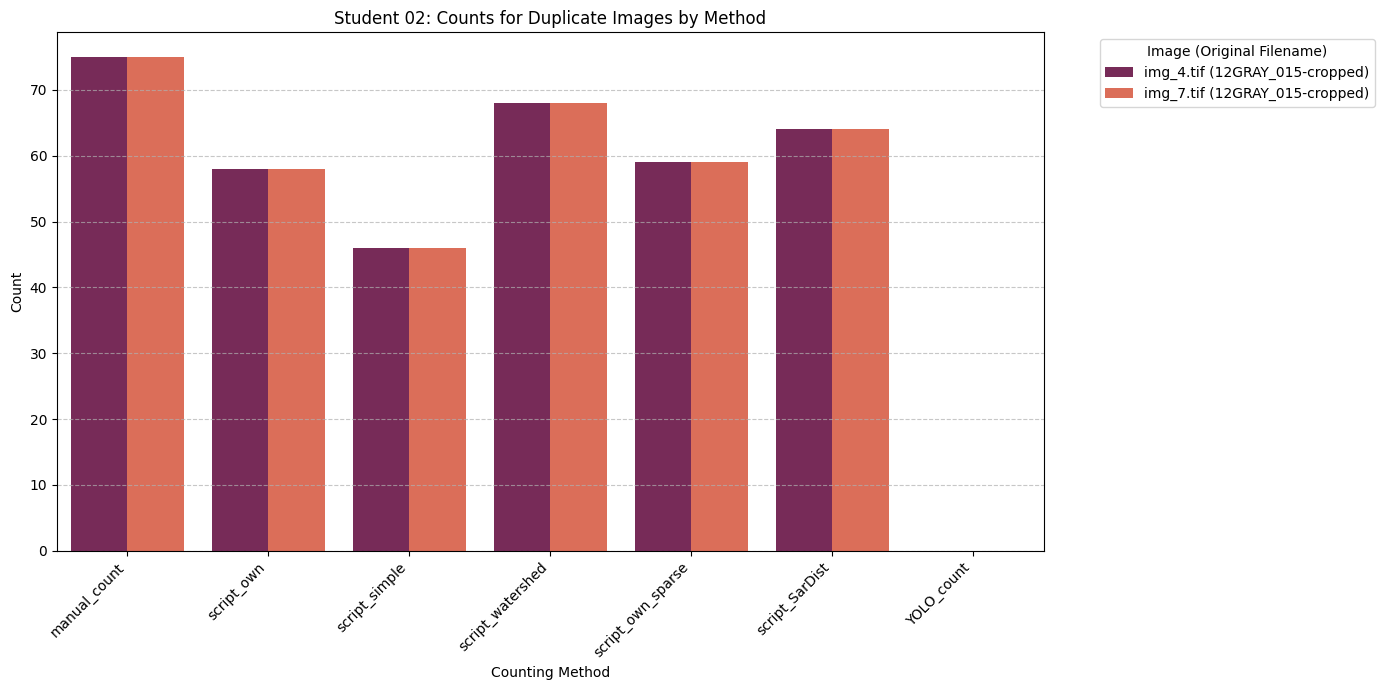

Chart saved for Student 07 at duplicate_counts_charts/student_07-duplicates-count.tiff


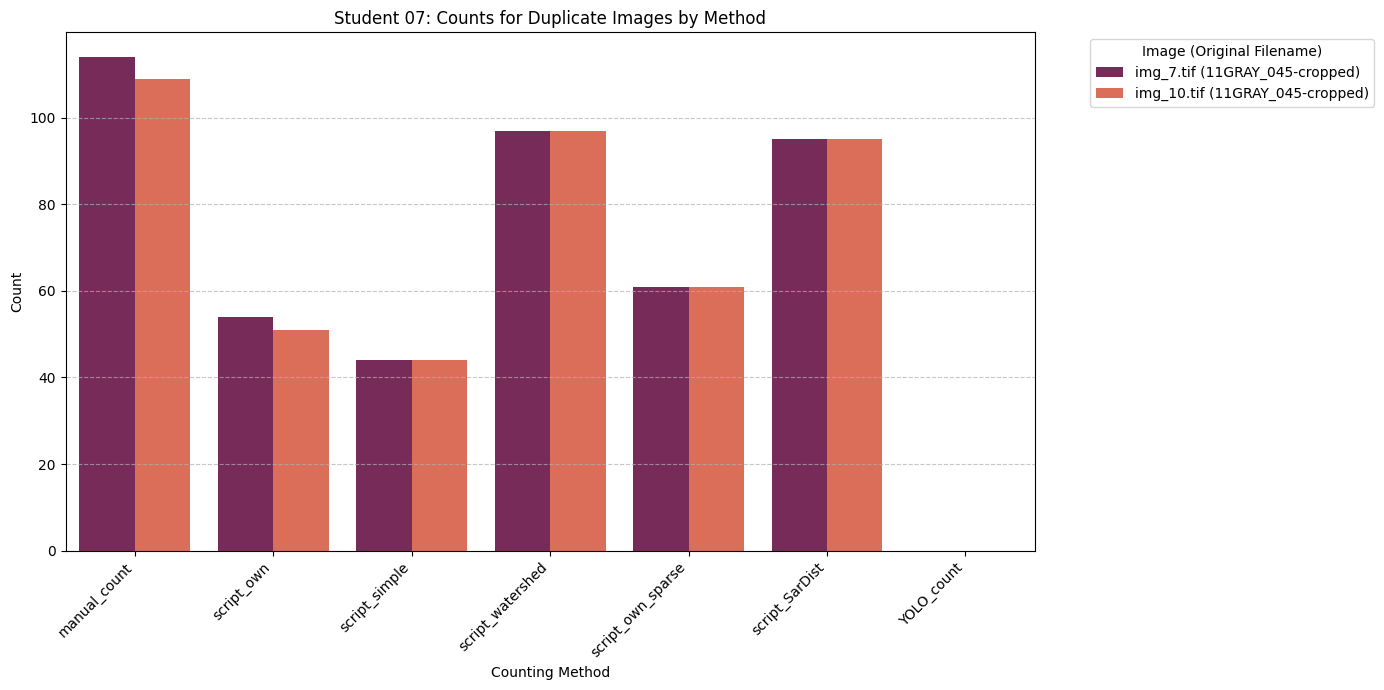

Chart saved for Student 09 at duplicate_counts_charts/student_09-duplicates-count.tiff


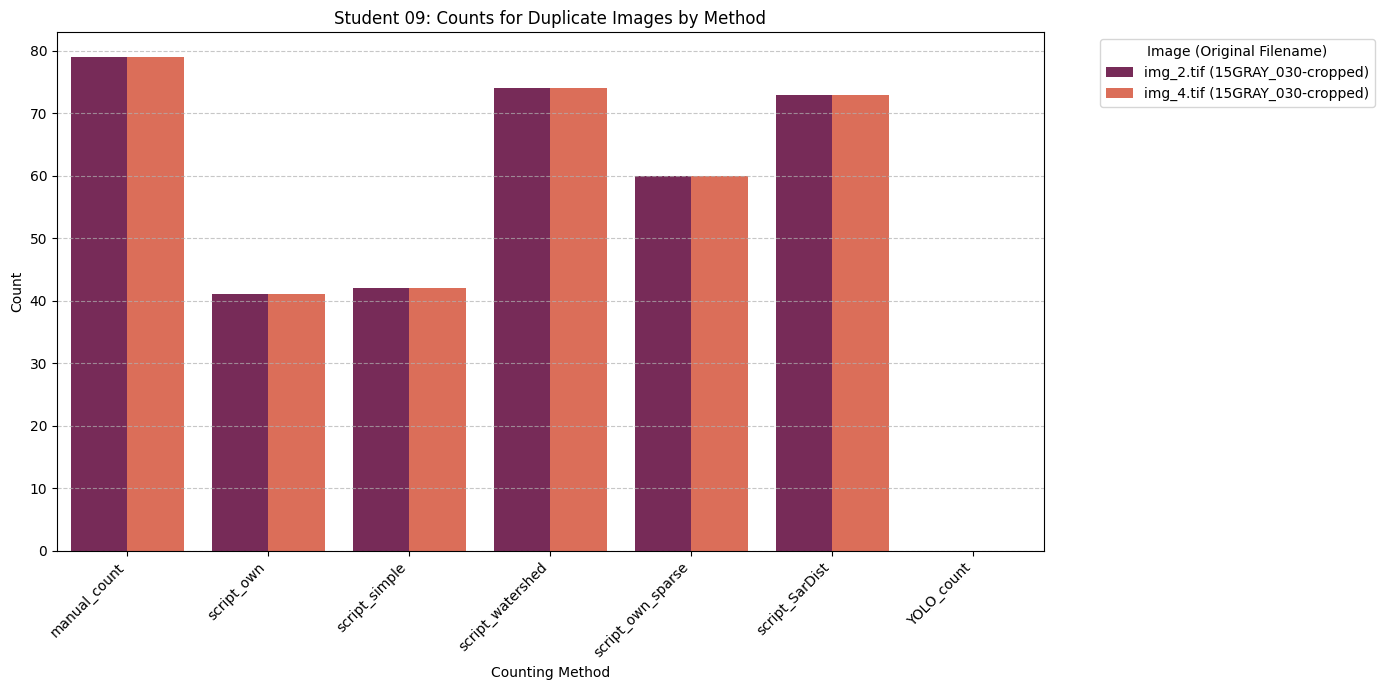

Chart saved for Student 03 at duplicate_counts_charts/student_03-duplicates-count.tiff


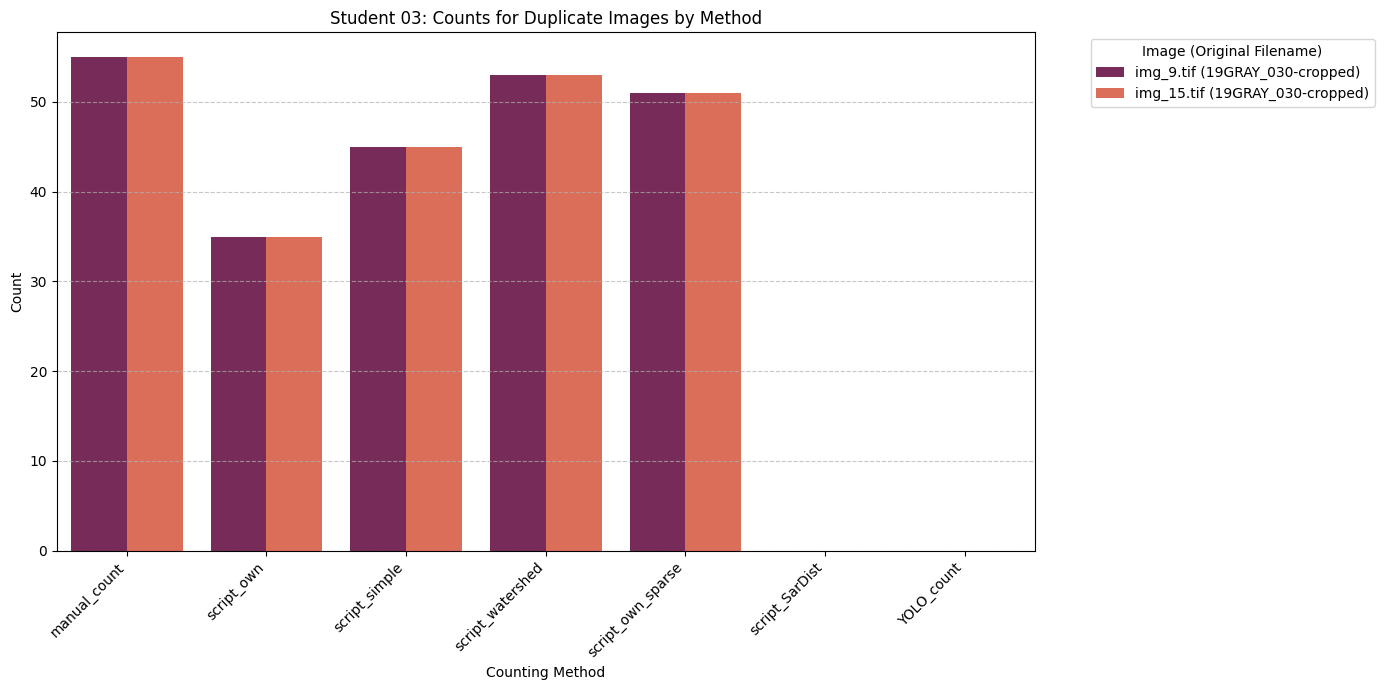

Chart saved for Student 08 at duplicate_counts_charts/student_08-duplicates-count.tiff


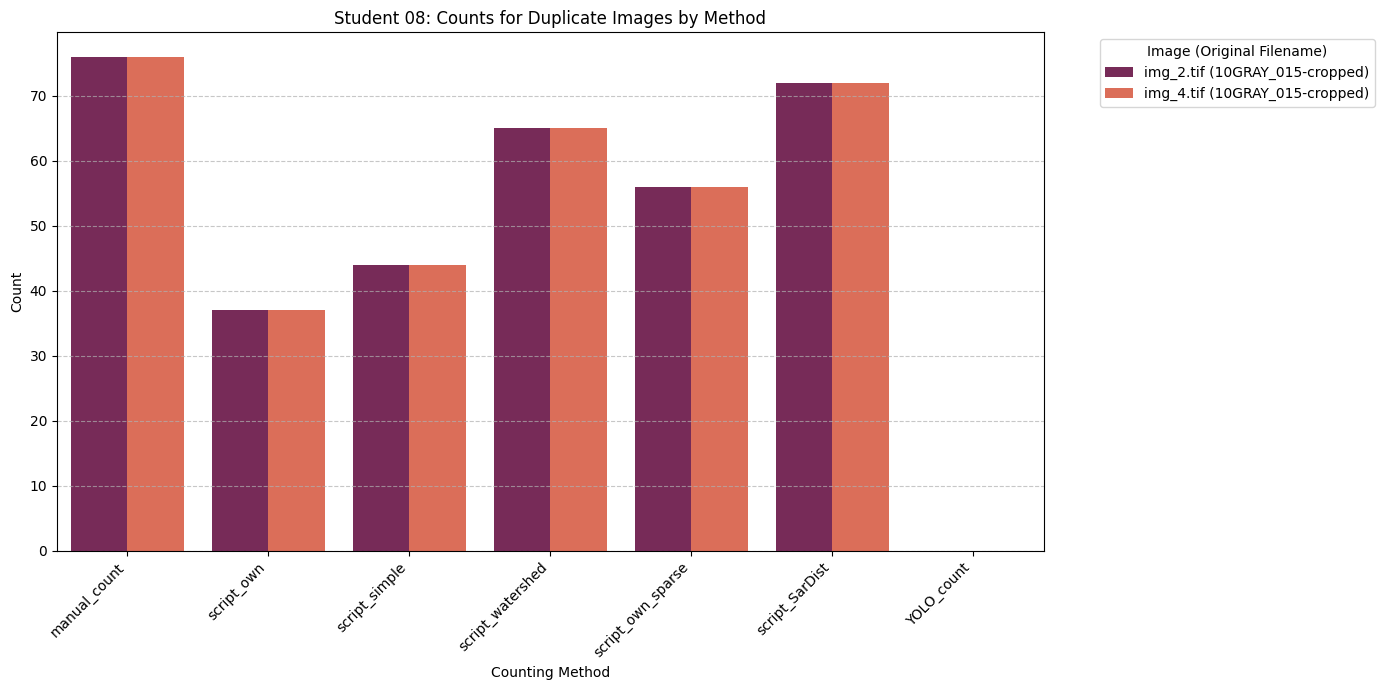

Chart saved for Student 05 at duplicate_counts_charts/student_05-duplicates-count.tiff


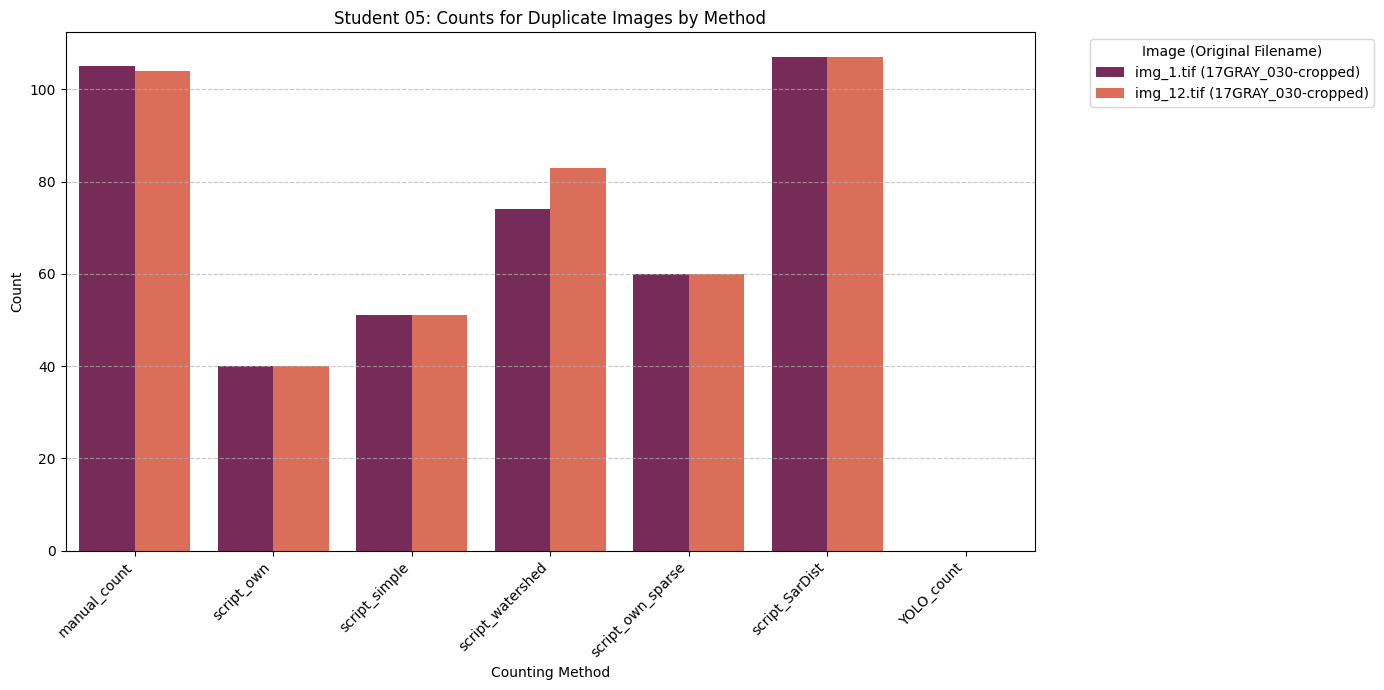

Chart saved for Student 04 at duplicate_counts_charts/student_04-duplicates-count.tiff


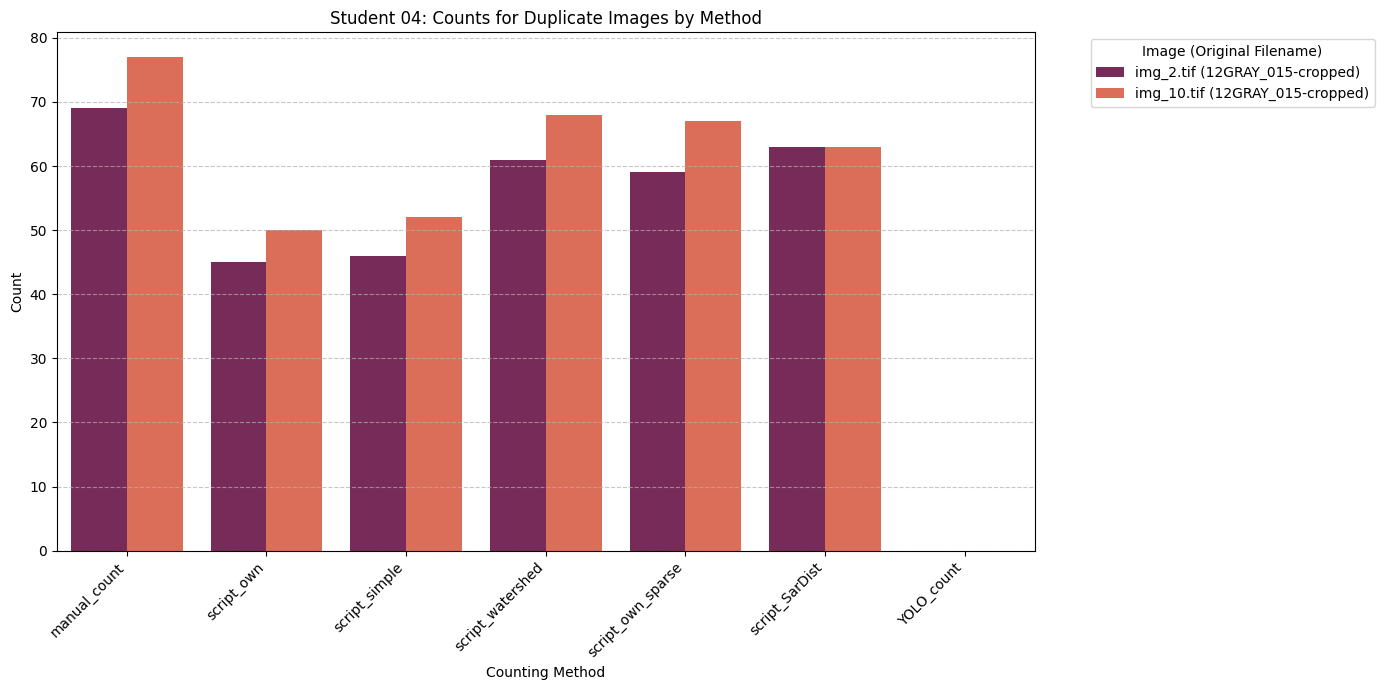

Finished generating all duplicate count charts.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Filter for duplicate images
duplicates_df = all_students_df[all_students_df['image_type'] == 'duplicate'].copy()

# Define the columns that contain count data
count_columns = [
    'manual_count', 'script_own', 'script_simple', 'script_watershed',
    'script_own_sparse', 'script_SarDist', 'YOLO_count'
]

# Get unique student numbers
unique_students = duplicates_df['student_folder'].unique()

print(f"Generating charts for {len(unique_students)} students...")

# Create a directory to save the plots if it doesn't exist
output_dir = 'duplicate_counts_charts'
os.makedirs(output_dir, exist_ok=True)

for student_folder in unique_students:
    student_number = student_folder.replace('student_', '')
    student_duplicates_df = duplicates_df[duplicates_df['student_folder'] == student_folder].copy()

    if not student_duplicates_df.empty:
        # Melt the DataFrame to long format for plotting
        melted_df = student_duplicates_df.melt(
            id_vars=['image_name', 'original_filename'],
            value_vars=count_columns,
            var_name='Counting Method',
            value_name='Count'
        )

        # Create a combined label for the images (for hue)
        melted_df['image_label'] = melted_df['image_name'] + ' (' + melted_df['original_filename'] + ')'

        plt.figure(figsize=(14, 7))
        sns.barplot(
            data=melted_df,
            x='Counting Method', # X-axis is now the counting method
            y='Count',
            hue='image_label',   # Hue is now the combined image label
            palette='rocket'
        )

        plt.title(f'Student {student_number}: Counts for Duplicate Images by Method')
        plt.xlabel('Counting Method') # X-axis label changed
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Image (Original Filename)', bbox_to_anchor=(1.05, 1), loc='upper left') # Legend title changed
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()

        # Save the chart
        filename = f"student_{student_number}-duplicates-count.tiff"
        filepath = os.path.join(output_dir, filename)
        plt.savefig(filepath, format='tiff', dpi=300)
        print(f"Chart saved for Student {student_number} at {filepath}")
        plt.show()
    else:
        print(f"No duplicate images found for Student {student_number}.")

print("Finished generating all duplicate count charts.")

### Alternative Visualization: Dot Plots for Duplicate Images

To better visualize the differences in counts across various methods for each duplicate image, a dot plot with small multiples can be very effective. This approach creates a separate plot for each duplicate image, showing the counts from all methods side-by-side. This allows for easier comparison of the values for each method on a per-image basis.

Generating combined dot plots for 7 students...
Combined dot plot saved for Student 02 at duplicate_counts_dot_plots_combined/student_02-duplicates-combined-dot-plot.tiff


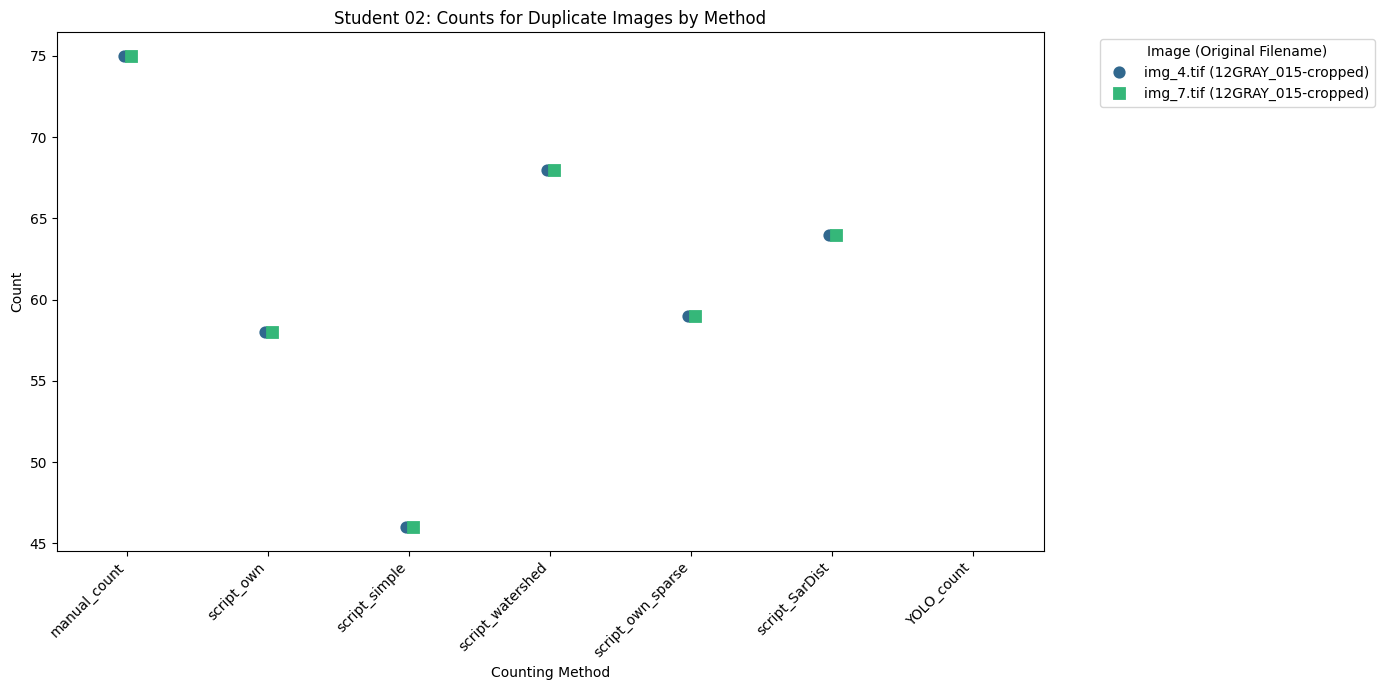

Combined dot plot saved for Student 07 at duplicate_counts_dot_plots_combined/student_07-duplicates-combined-dot-plot.tiff


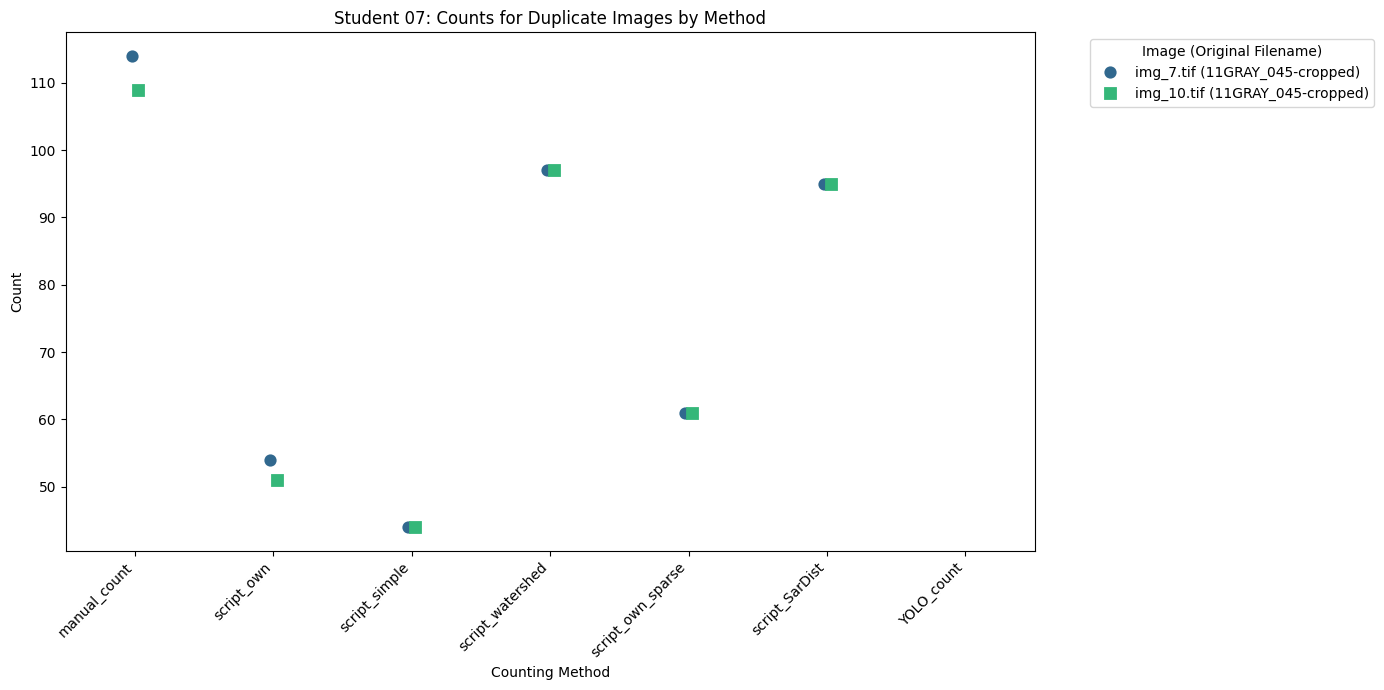

Combined dot plot saved for Student 09 at duplicate_counts_dot_plots_combined/student_09-duplicates-combined-dot-plot.tiff


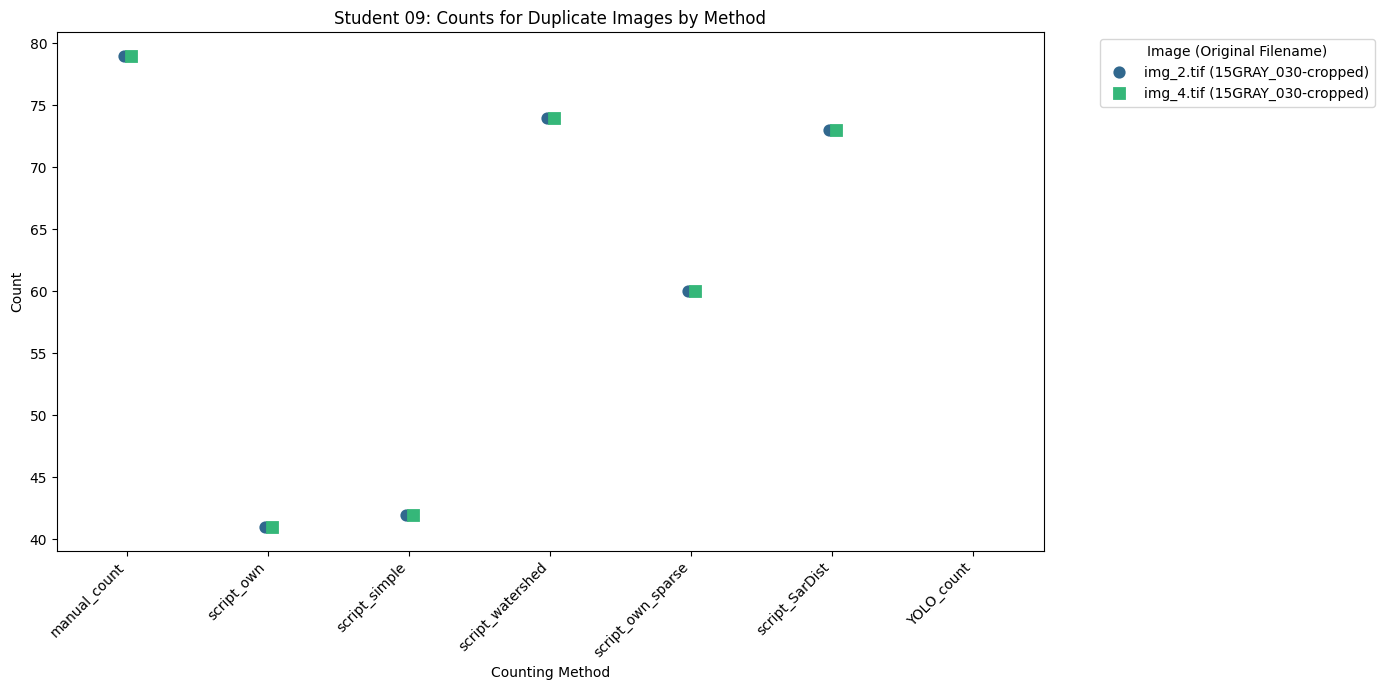

Combined dot plot saved for Student 03 at duplicate_counts_dot_plots_combined/student_03-duplicates-combined-dot-plot.tiff


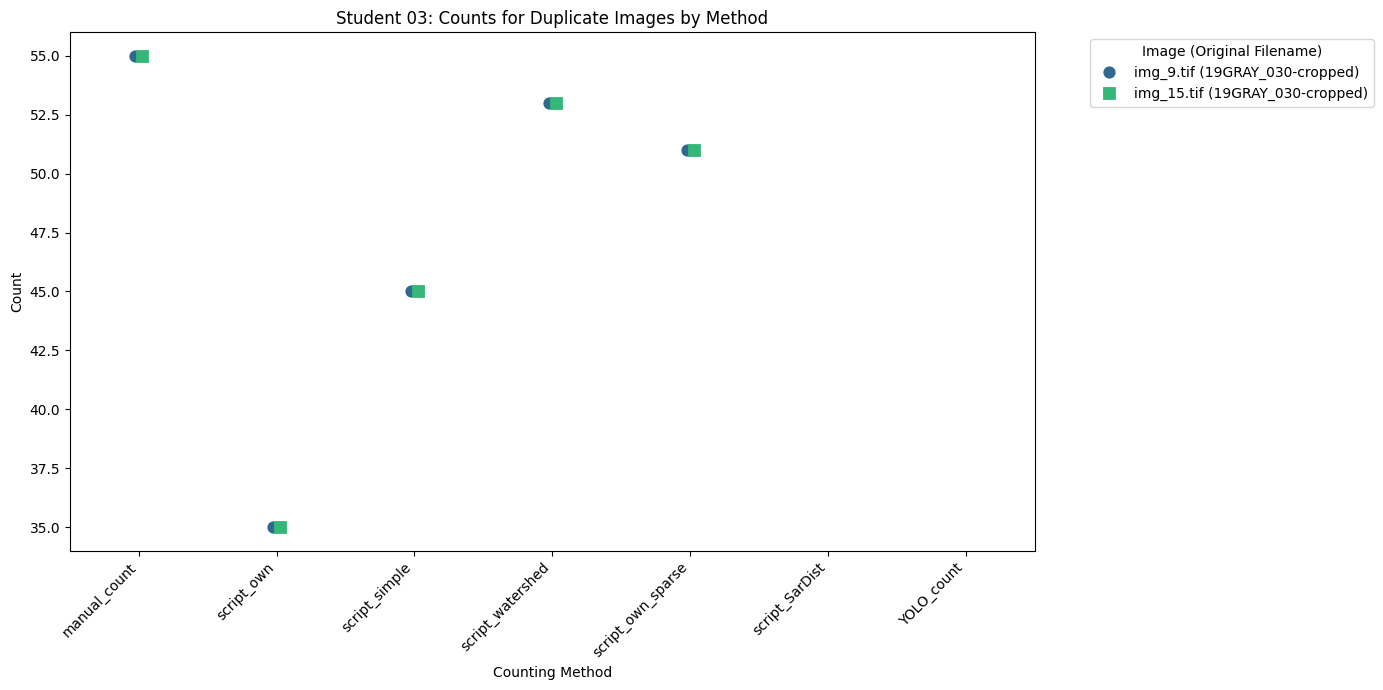

Combined dot plot saved for Student 08 at duplicate_counts_dot_plots_combined/student_08-duplicates-combined-dot-plot.tiff


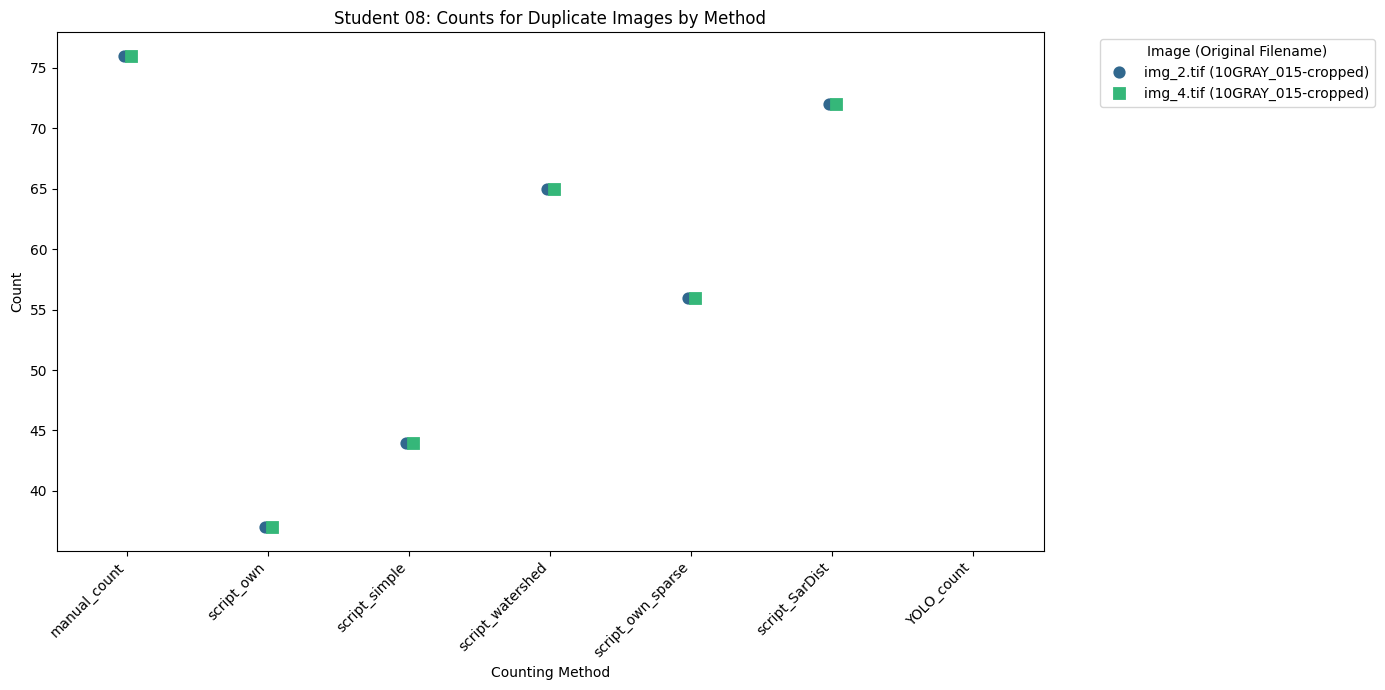

Combined dot plot saved for Student 05 at duplicate_counts_dot_plots_combined/student_05-duplicates-combined-dot-plot.tiff


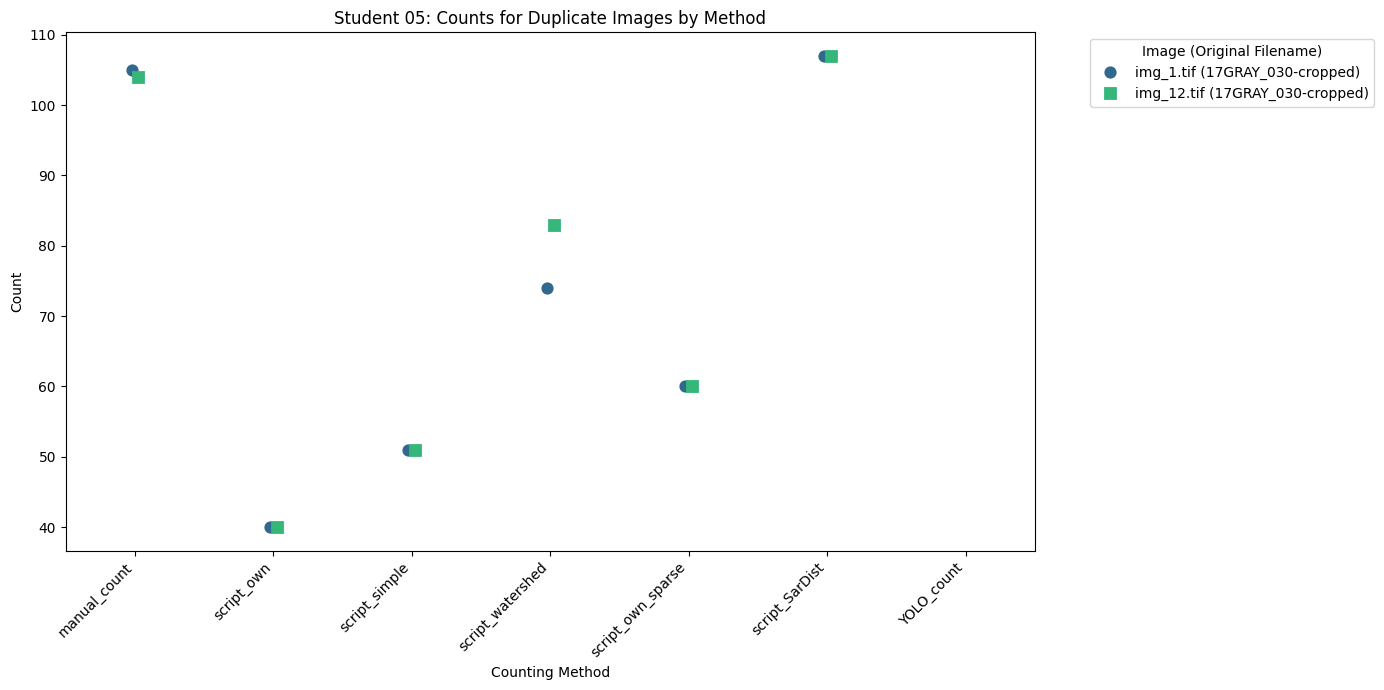

Combined dot plot saved for Student 04 at duplicate_counts_dot_plots_combined/student_04-duplicates-combined-dot-plot.tiff


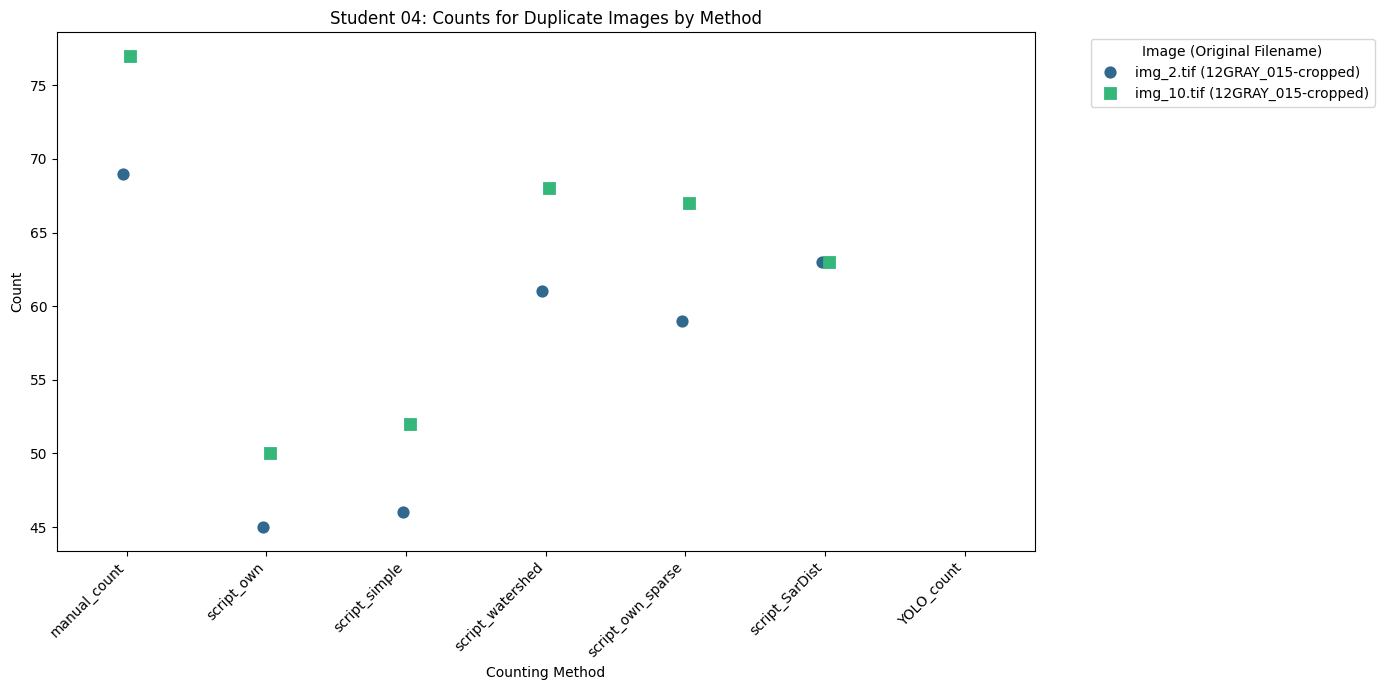

Finished generating all combined duplicate count dot plots.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Filter for duplicate images (re-using the duplicates_df from previous steps)
duplicates_df = all_students_df[all_students_df['image_type'] == 'duplicate'].copy()

# Define the columns that contain count data
count_columns = [
    'manual_count', 'script_own', 'script_simple', 'script_watershed',
    'script_own_sparse', 'script_SarDist', 'YOLO_count'
]

# Get unique student numbers
unique_students = duplicates_df['student_folder'].unique()

print(f"Generating combined dot plots for {len(unique_students)} students...")

# Create a directory to save the plots if it doesn't exist
output_dir_dot_plots = 'duplicate_counts_dot_plots_combined'
os.makedirs(output_dir_dot_plots, exist_ok=True)

# Define a list of markers to differentiate images, assuming up to 7 images per student
markers = ['o', 's', '^', 'D', 'v', 'P', 'X']

for student_folder in unique_students:
    student_number = student_folder.replace('student_', '')
    student_duplicates_df = duplicates_df[duplicates_df['student_folder'] == student_folder].copy()

    if not student_duplicates_df.empty:
        # Melt the DataFrame to long format for plotting
        melted_df = student_duplicates_df.melt(
            id_vars=['image_name', 'original_filename'],
            value_vars=count_columns,
            var_name='Counting Method',
            value_name='Count'
        )

        # Create a combined label for the images
        melted_df['image_label'] = melted_df['image_name'] + ' (' + melted_df['original_filename'] + ')'

        plt.figure(figsize=(14, 7))
        sns.pointplot(
            data=melted_df,
            x='Counting Method',
            y='Count',
            hue='image_label', # Use image_label for hue to differentiate images
            markers=markers[:len(melted_df['image_label'].unique())], # Assign unique markers
            linestyles=[''] * len(melted_df['image_label'].unique()), # No lines between points for clarity
            dodge=True,        # Position points for different hues side-by-side
            palette='viridis'  # Colormap for different images
        )

        plt.title(f'Student {student_number}: Counts for Duplicate Images by Method')
        plt.xlabel('Counting Method')
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Image (Original Filename)', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(False)
        plt.tight_layout()

        # Save the chart
        filename = f"student_{student_number}-duplicates-combined-dot-plot.tiff"
        filepath = os.path.join(output_dir_dot_plots, filename)
        plt.savefig(filepath, format='tiff', dpi=300)
        print(f"Combined dot plot saved for Student {student_number} at {filepath}")
        plt.show()
    else:
        print(f"No duplicate images found for Student {student_number}.")

print("Finished generating all combined duplicate count dot plots.")

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
import os

# Ensure base_repo_path is defined (it was defined in d88UGC8QS_n6)
base_repo_path = '/content/semester-project-2026/'

# Create a 'gt_mask_full_path' column in all_students_df
# This assumes GT masks are in a 'gt' subfolder and have a .tif extension
# while the 'path' column in all_students_df might have .tiff.
all_students_df['gt_mask_full_path'] = all_students_df['path'].astype(str).apply(
    lambda x: os.path.join(base_repo_path, 'gt', x).replace('.tiff', '.tif')
)
print("Added 'gt_mask_full_path' to all_students_df.")

# Create a 'label_map_full_path' column in all_students_df (moved from d88UGC8QS_n6)
# This assumes label maps are in a 'labels' subfolder and have a .tif extension
all_students_df['label_map_full_path'] = all_students_df['path'].astype(str).apply(
    lambda x: os.path.join(base_repo_path, 'labels', x).replace('.tiff', '.tif')
)
print("Added 'label_map_full_path' to all_students_df.") # Added print for clarity

# Filter for calibration images (as per previous cells, these are the ones with available masks for comparison)
calibration_comparison_df = all_students_df[all_students_df['image_type'] == 'calibration'].copy()

# List to store results
comparison_results = []

print(f"Starting mask comparison for {len(calibration_comparison_df)} calibration entries...")

for index, row in calibration_comparison_df.iterrows():
    student_mask_path = row['label_map_full_path']
    gt_mask_path = row['gt_mask_full_path']
    original_filename = row['original_filename']
    student_id = row['student'].replace('student_', '')

    student_mask = None
    gt_mask = None
    img_width, img_height = None, None

    # Load Student Mask
    if os.path.exists(student_mask_path):
        try:
            student_mask_img = Image.open(student_mask_path).convert('L') # Ensure grayscale
            img_width, img_height = student_mask_img.size
            student_mask = (np.array(student_mask_img) > 0).astype(bool) # Binarize: any non-zero pixel becomes True
        except Exception as e:
            print(f"Error loading student mask for {original_filename}, student {student_id}: {e}")
            continue # Skip this entry if student mask fails to load
    else:
        print(f"Student mask not found: {student_mask_path}")
        continue # Skip if student mask not found

    # Load GT Mask
    if os.path.exists(gt_mask_path):
        try:
            gt_mask_img = Image.open(gt_mask_path).convert('L') # Ensure grayscale
            # Resize GT mask to match student mask dimensions if necessary
            if gt_mask_img.size != (img_width, img_height):
                gt_mask_img = gt_mask_img.resize((img_width, img_height), Image.NEAREST)
            gt_mask = (np.array(gt_mask_img) > 0).astype(bool) # Binarize
        except Exception as e:
            print(f"Error loading GT mask for {original_filename}, student {student_id}: {e}")
            continue # Skip this entry if GT mask fails to load
    else:
        print(f"GT mask not found: {gt_mask_path}")
        continue # Skip if GT mask not found

    # Ensure both masks are boolean arrays for logical operations
    if student_mask is not None and gt_mask is not None:
        # Flatten masks for metrics that expect 1D arrays or pixel-wise comparison
        student_mask_flat = student_mask.flatten()
        gt_mask_flat = gt_mask.flatten()

        # Calculate IoU (Jaccard Index)
        intersection = np.sum(np.logical_and(student_mask, gt_mask))
        union = np.sum(np.logical_or(student_mask, gt_mask))
        iou = intersection / union if union != 0 else 0.0

        # Calculate F1-Score (Dice Coefficient)
        f1_score = (2 * intersection) / (np.sum(student_mask) + np.sum(gt_mask)) if (np.sum(student_mask) + np.sum(gt_mask)) != 0 else 0.0

        # For accuracy metrics, need TP, TN, FP, FN
        tp = np.sum(np.logical_and(student_mask_flat, gt_mask_flat)) # True Positive
        tn = np.sum(np.logical_and(~student_mask_flat, ~gt_mask_flat)) # True Negative
        fp = np.sum(np.logical_and(student_mask_flat, ~gt_mask_flat)) # False Positive
        fn = np.sum(np.logical_and(~student_mask_flat, gt_mask_flat)) # False Negative

        total_pixels = student_mask_flat.size

        # Accuracy
        accuracy = (tp + tn) / total_pixels if total_pixels != 0 else 0.0

        # Balanced Accuracy
        sensitivity = tp / (tp + fn) if (tp + fn) != 0 else 0.0 # Recall
        specificity = tn / (tn + fp) if (tn + fp) != 0 else 0.0
        balanced_accuracy = (sensitivity + specificity) / 2

        comparison_results.append({
            'original_filename': original_filename,
            'student_id': student_id,
            'IoU': iou,
            'F1_Score': f1_score,
            'Accuracy': accuracy,
            'Balanced_Accuracy': balanced_accuracy,
            'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
        })

mask_comparison_df = pd.DataFrame(comparison_results)

if not mask_comparison_df.empty:
    print("\nMask Comparison Statistics (Student Label vs. Ground Truth):")
    display(mask_comparison_df.head())

    print("\nSummary Statistics for all metrics:")
    display(mask_comparison_df[['IoU', 'F1_Score', 'Accuracy', 'Balanced_Accuracy']].describe())
else:
    print("No mask comparison results could be generated.")

Added 'gt_mask_full_path' to all_students_df.
Added 'label_map_full_path' to all_students_df.
Starting mask comparison for 28 calibration entries...
Student mask not found: /content/semester-project-2026/labels/student_03/img_2.tif
Student mask not found: /content/semester-project-2026/labels/student_03/img_4.tif
Student mask not found: /content/semester-project-2026/labels/student_03/img_7.tif
Student mask not found: /content/semester-project-2026/labels/student_03/img_10.tif
Student mask not found: /content/semester-project-2026/labels/student_08/img_3.tif
Student mask not found: /content/semester-project-2026/labels/student_08/img_6.tif
Student mask not found: /content/semester-project-2026/labels/student_08/img_11.tif
Student mask not found: /content/semester-project-2026/labels/student_08/img_13.tif
Student mask not found: /content/semester-project-2026/labels/student_04/img_3.tif
Student mask not found: /content/semester-project-2026/labels/student_04/img_4.tif
Student mask not f

,original_filename,student_id,IoU,F1_Score,Accuracy,Balanced_Accuracy,TP,TN,FP,FN
0,9GRAY_015-cropped,02,0.602825,0.752203,0.930588,0.959992,23770,186194,15596,65
1,1GRAY_030-cropped,02,0.545568,0.705977,0.936816,0.965249,17115,194254,14235,21
2,4GRAY_000-cropped,02,0.533827,0.696072,0.910639,0.950226,23088,182375,20162,0
3,16GRAY_045-cropped,02,0.593860,0.745185,0.942360,0.968335,19016,193604,12997,8
4,4GRAY_000-cropped,07,0.501582,0.668072,0.946947,0.758581,12046,201609,928,11042



Summary Statistics for all metrics:


,IoU,F1_Score,Accuracy,Balanced_Accuracy
count,16.000000,16.000000,16.000000,16.000000
mean,0.696399,0.814216,0.962998,0.916330
std,0.129844,0.095073,0.022926,0.072008
min,0.470576,0.639989,0.910639,0.740441
25%,0.581787,0.735383,0.945801,0.904295
50%,0.774875,0.873113,0.973866,0.948480
75%,0.795595,0.886161,0.981576,0.963205
max,0.833940,0.909452,0.982746,0.974442


### Visualization of Mask Comparison Metrics

This visualization provides a clear overview of the agreement metrics (IoU, F1-Score, Accuracy, and Balanced Accuracy) between student-generated masks and ground truth for each calibration image. Each facet represents a different metric, with bars grouped by original filename and colored by student ID.

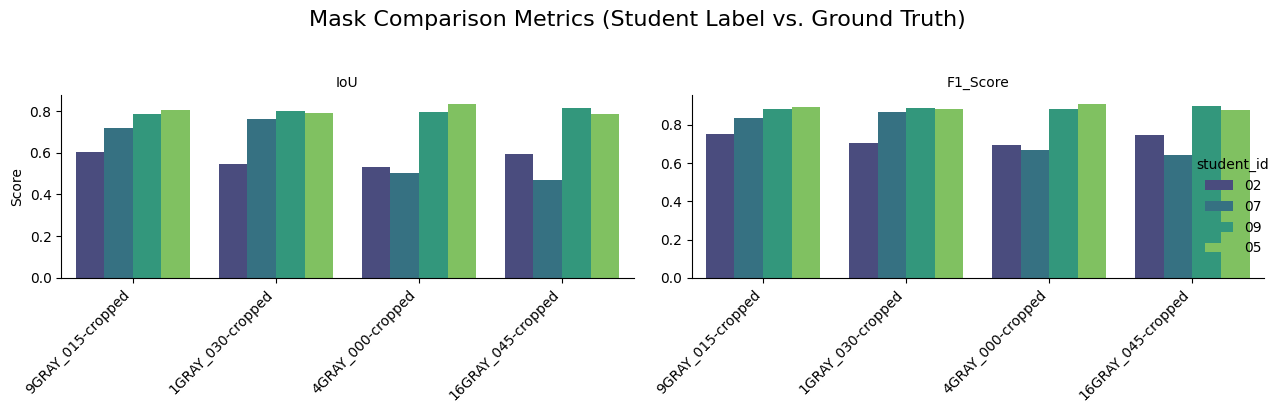

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the mask_comparison_df to long format for plotting
metrics_to_plot = ['IoU', 'F1_Score']
melted_metrics_df = mask_comparison_df.melt(
    id_vars=['original_filename', 'student_id'],
    value_vars=metrics_to_plot,
    var_name='Metric',
    value_name='Score'
)

# Use catplot for faceted bar plots
g = sns.catplot(
    data=melted_metrics_df,
    x='original_filename',
    y='Score',
    hue='student_id',
    col='Metric', # Facet by each metric
    col_wrap=2, # Two plots per row
    kind='bar',
    height=4, aspect=1.5,
    palette='viridis',
    errorbar=None, # No error bars for single values
    sharey=False # Allow each facet to have its own y-axis scale
)

g.set_axis_labels("", "Score") # Remove x-axis label, it's rotated
g.set_titles(col_template="{col_name}") # Set title for each facet
g.set_xticklabels(rotation=45, ha='right')
g.fig.suptitle('Mask Comparison Metrics (Student Label vs. Ground Truth)', y=1.02, fontsize=16) # Overall title
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

#### Intra-rater Variability for Duplicate Counts

Intra-rater variability assesses the consistency of a single student when performing repeated measurements (in this case, counting objects in duplicate images). We will analyze the spread of counts for each student for the same 'original_filename' that appears as a duplicate, using the `all_students_df` to identify these instances.

Intra-rater Variability for Duplicate Counts (Standard Deviation per student and original image):


,student_id,original_filename,counting_method,mean_count,std_dev
0,02,12GRAY_015-cropped,manual_count,75.0,0.0
1,02,12GRAY_015-cropped,script_own,58.0,0.0
2,02,12GRAY_015-cropped,script_simple,46.0,0.0
3,02,12GRAY_015-cropped,script_watershed,68.0,0.0
4,02,12GRAY_015-cropped,script_own_sparse,59.0,0.0


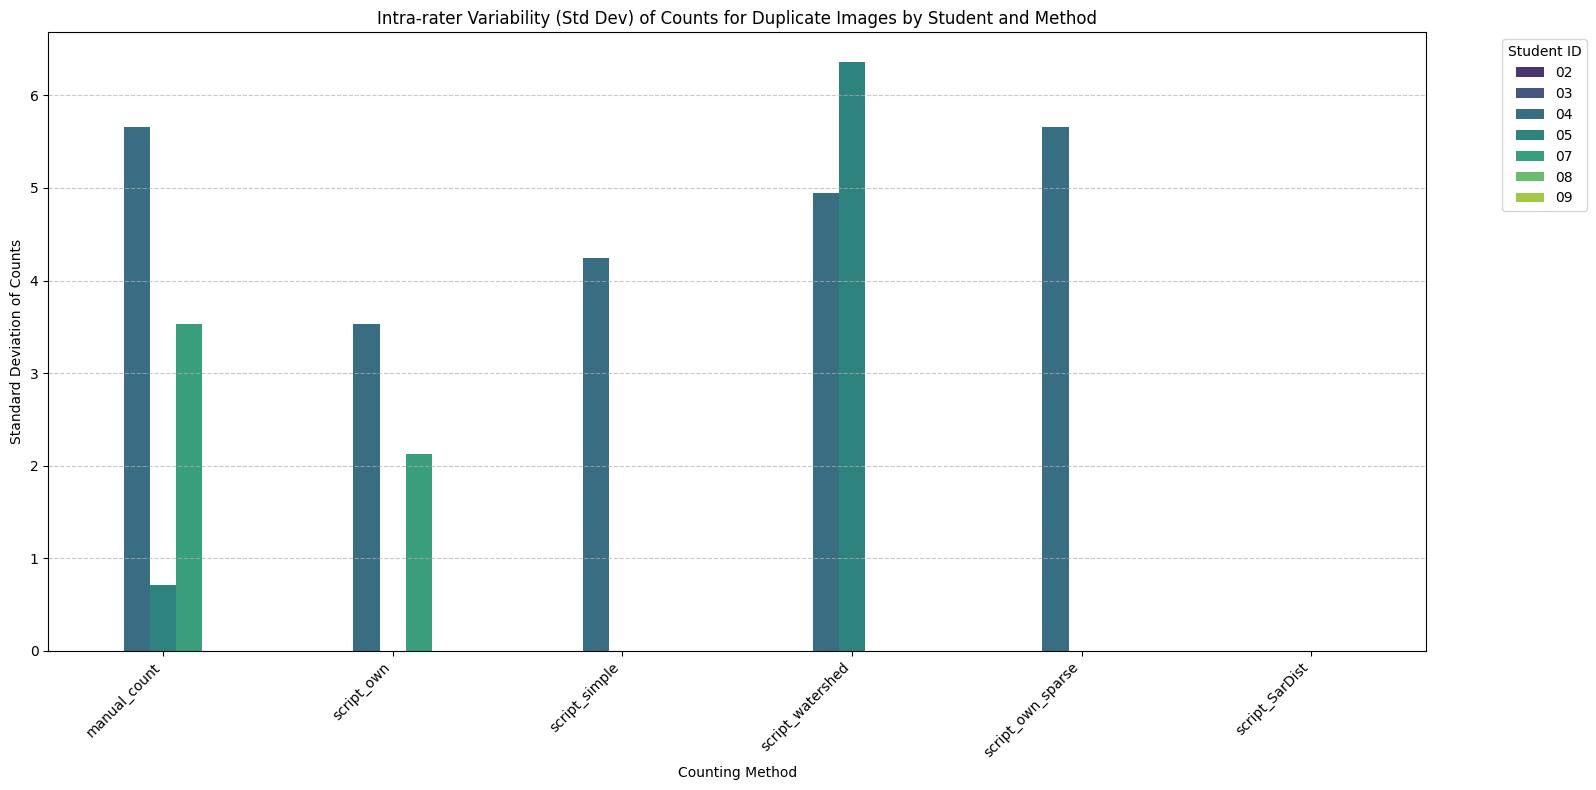

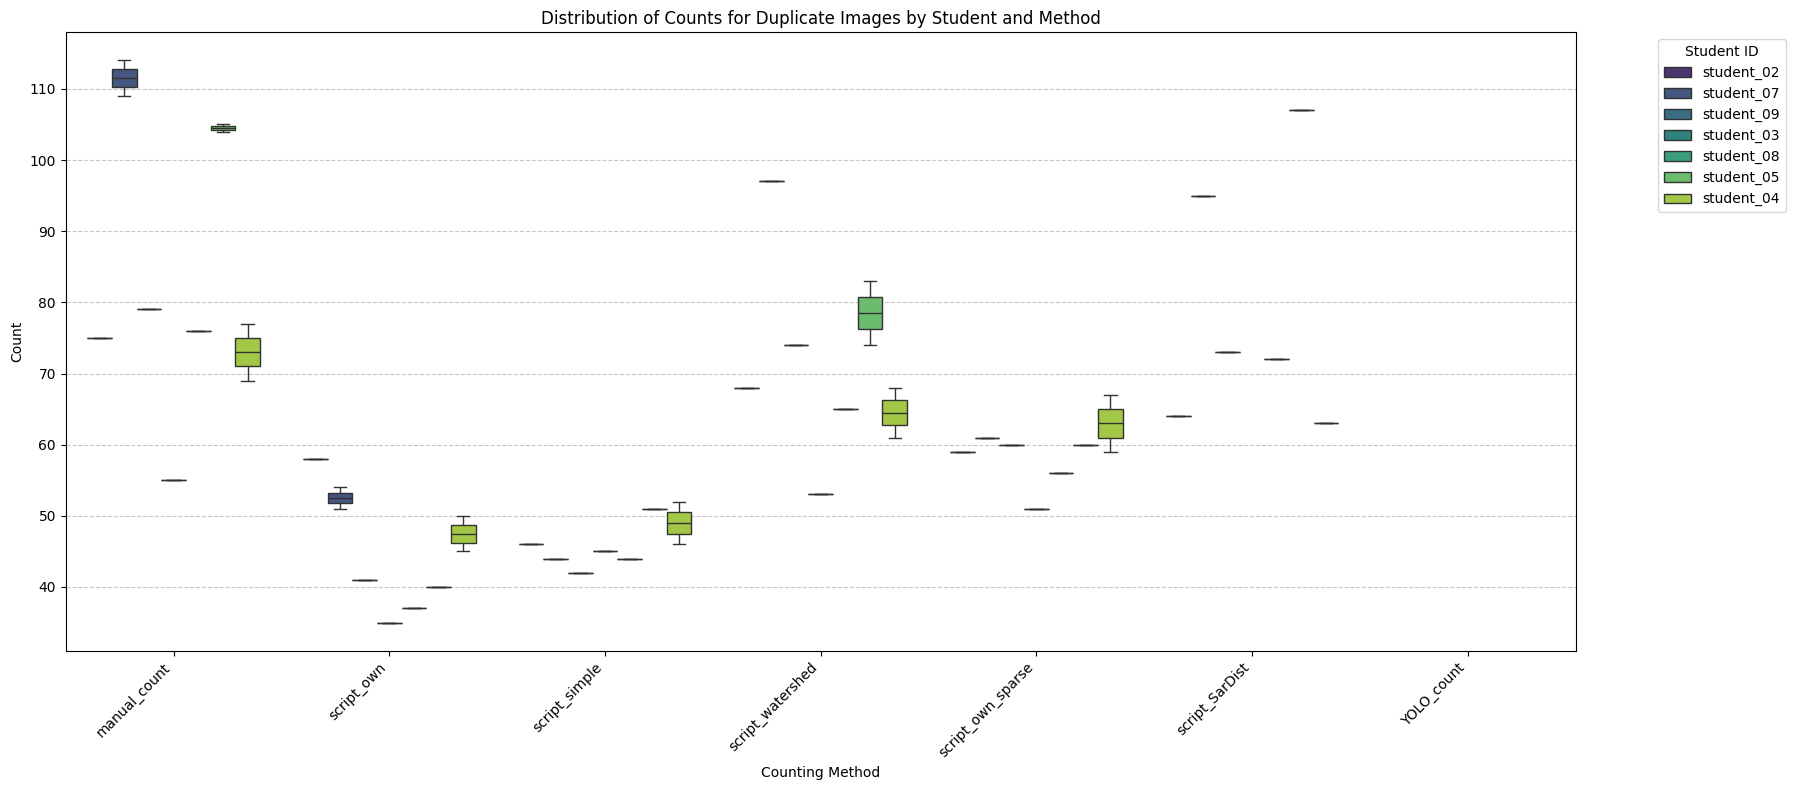

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for duplicate images
duplicate_counts_df = all_students_df[all_students_df['image_type'] == 'duplicate'].copy()

# Define the counting columns to analyze
count_cols = [
    'manual_count', 'script_own', 'script_simple', 'script_watershed',
    'script_own_sparse', 'script_SarDist', 'YOLO_count'
]

# Prepare a list to store intra-rater variability statistics
intra_rater_variability = []

# Group by student and original filename to find variability for duplicates
for (student_folder, original_filename), group_df in duplicate_counts_df.groupby(['student_folder', 'original_filename']):
    student_id = student_folder.replace('student_', '')

    # Only consider groups with more than one entry (i.e., actual duplicates for that student)
    if len(group_df) > 1:
        for col in count_cols:
            if col in group_df.columns:
                counts = group_df[col].dropna() # Drop NaN values for std calculation
                if len(counts) > 1:
                    std_dev = counts.std()
                    mean_count = counts.mean()
                    intra_rater_variability.append({
                        'student_id': student_id,
                        'original_filename': original_filename,
                        'counting_method': col,
                        'mean_count': mean_count,
                        'std_dev': std_dev
                    })

intra_rater_df = pd.DataFrame(intra_rater_variability)

if not intra_rater_df.empty:
    print("Intra-rater Variability for Duplicate Counts (Standard Deviation per student and original image):")
    display(intra_rater_df.head())

    # Visualize the intra-rater variability
    plt.figure(figsize=(16, 8))
    sns.barplot(
        data=intra_rater_df,
        x='counting_method',
        y='std_dev',
        hue='student_id',
        palette='viridis'
    )
    plt.title('Intra-rater Variability (Std Dev) of Counts for Duplicate Images by Student and Method')
    plt.xlabel('Counting Method')
    plt.ylabel('Standard Deviation of Counts')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Student ID', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Another visualization: box plots for counts of duplicates for each student and method
    plt.figure(figsize=(18, 8))
    sns.boxplot(
        data=duplicate_counts_df.melt(id_vars=['student_folder', 'original_filename'], value_vars=count_cols, var_name='Counting Method', value_name='Count'),
        x='Counting Method',
        y='Count',
        hue='student_folder',
        palette='viridis'
    )
    plt.title('Distribution of Counts for Duplicate Images by Student and Method')
    plt.xlabel('Counting Method')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Student ID', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

else:
    print("No intra-rater variability could be calculated for duplicate counts (possibly no students had multiple counts for the same duplicate image).")